## import  libraries 
# Logistic Regression 
The type of  supervised ML in which predict the value 0 and 1 so my prolem is the binary classifaction

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns


In [2]:
dataset=pd.read_csv("C:\\Users\\muham\\OneDrive\\Documents\\DIP lacture 6th semester\\heart_cleveland_upload.csv")

In [3]:
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [4]:
tableINfo=pd.read_csv("C:\\Users\\muham\\OneDrive\\Documents\\DIP lacture 6th semester\\table.csv")

In [5]:
tableINfo

,Feature,Full Name,What it Means,Type,Values / Range
0,age,Age,Patient's age in years,Numerical,29 – 77
1,sex,Sex,Gender of the patient,Categorical,"0 = Female, 1 = Male"
2,cp,Chest Pain Type,Type of chest pain the patient feels,Categorical,0 = Typical Angina\n1 = Atypical Angina\n2 = N...
3,trestbps,Resting Blood Pressure,Blood pressure when resting (in mm Hg),Numerical,94 – 200
4,chol,Serum Cholesterol,Cholesterol level in blood (mg/dl),Numerical,126 – 564
5,fbs,Fasting Blood Sugar,Is fasting blood sugar > 120 mg/dl?,Categorical,0 = False (Normal)\n1 = True (High)
6,restecg,Resting ECG Results,Electrocardiogram results at rest,Categorical,0 = Normal\n1 = ST-T wave abnormality\n2 = Lef...
7,thalach,Maximum Heart Rate Achieved,Highest heart rate during exercise,Numerical,71 – 202
8,exang,Exercise Induced Angina,Did exercise cause chest pain?,Categorical,0 = No\n1 = Yes
9,oldpeak,ST Depression Induced by Exercise,How much the ST segment drops during exercise ...,Numerical,0.0 – 6.2


## vasulize the data

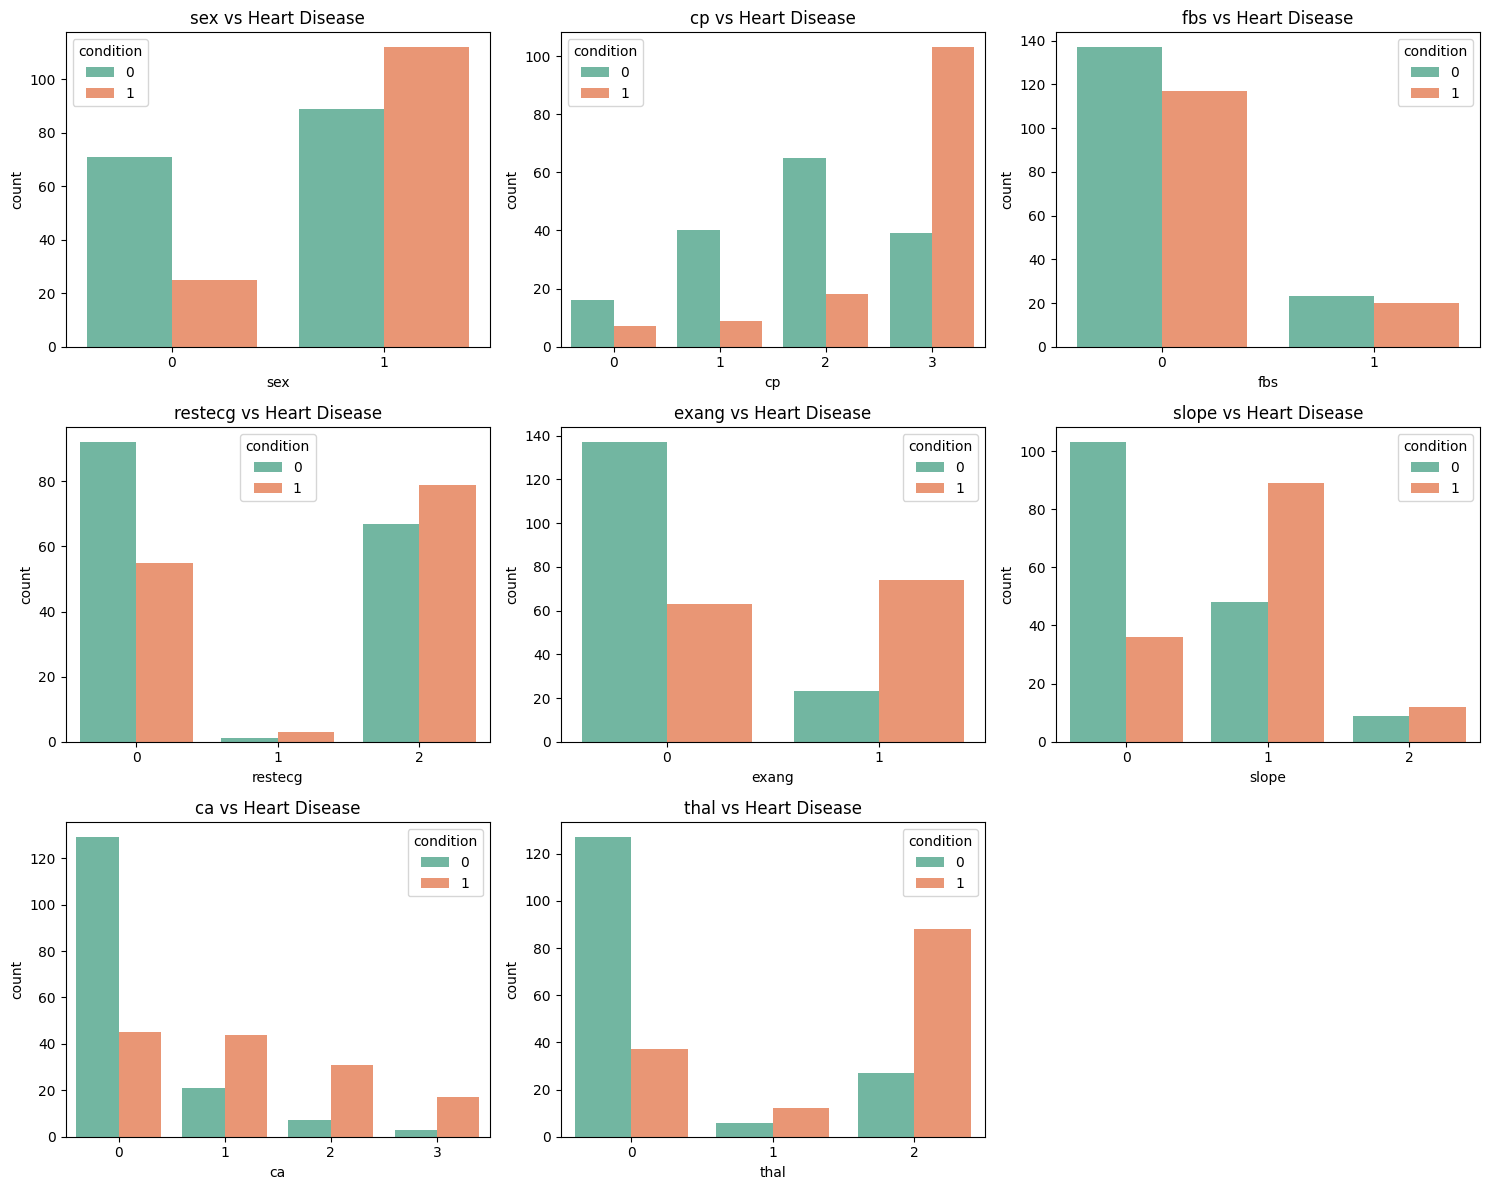

In [6]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(cat_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=feature, hue='condition', data=dataset, palette='Set2')
    plt.title(f'{feature} vs Heart Disease')
    plt.tight_layout()

plt.show()

## to see the missing value 

In [7]:
dataset.isnull().sum
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


Training samples: 222
Testing samples: 75

MODEL PERFORMANCE
Accuracy: 86.67 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.89        40
           1       0.96      0.74      0.84        35

    accuracy                           0.87        75
   macro avg       0.89      0.86      0.86        75
weighted avg       0.88      0.87      0.86        75

Confusion Matrix:


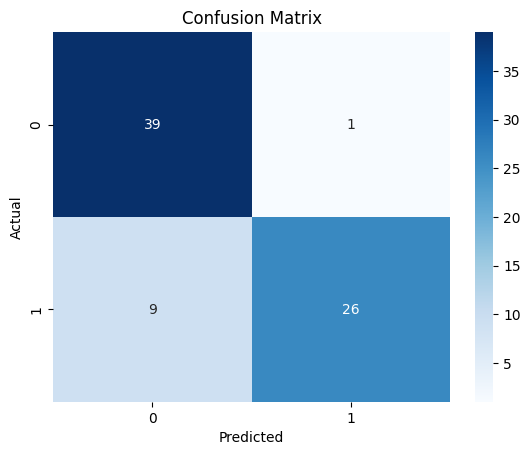

In [8]:

from sklearn.preprocessing import StandardScaler



# ====================== 3. Prepare Features and Target ======================
X = dataset.drop('condition', axis=1)      # All features except target
y = dataset['condition']                   # Target variable

# ====================== 4. Split Data into Train & Test ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25,      # 25% for testing
    random_state=42,     # For reproducibility
    stratify=y           # Keep same ratio of classes
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ====================== 5. Feature Scaling (Important for Logistic Regression) ======================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ====================== 6. Train the Model ======================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# ====================== 7. Make Predictions ======================
y_pred = model.predict(X_test_scaled)

# ====================== 8. Evaluate the Model ======================
print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()